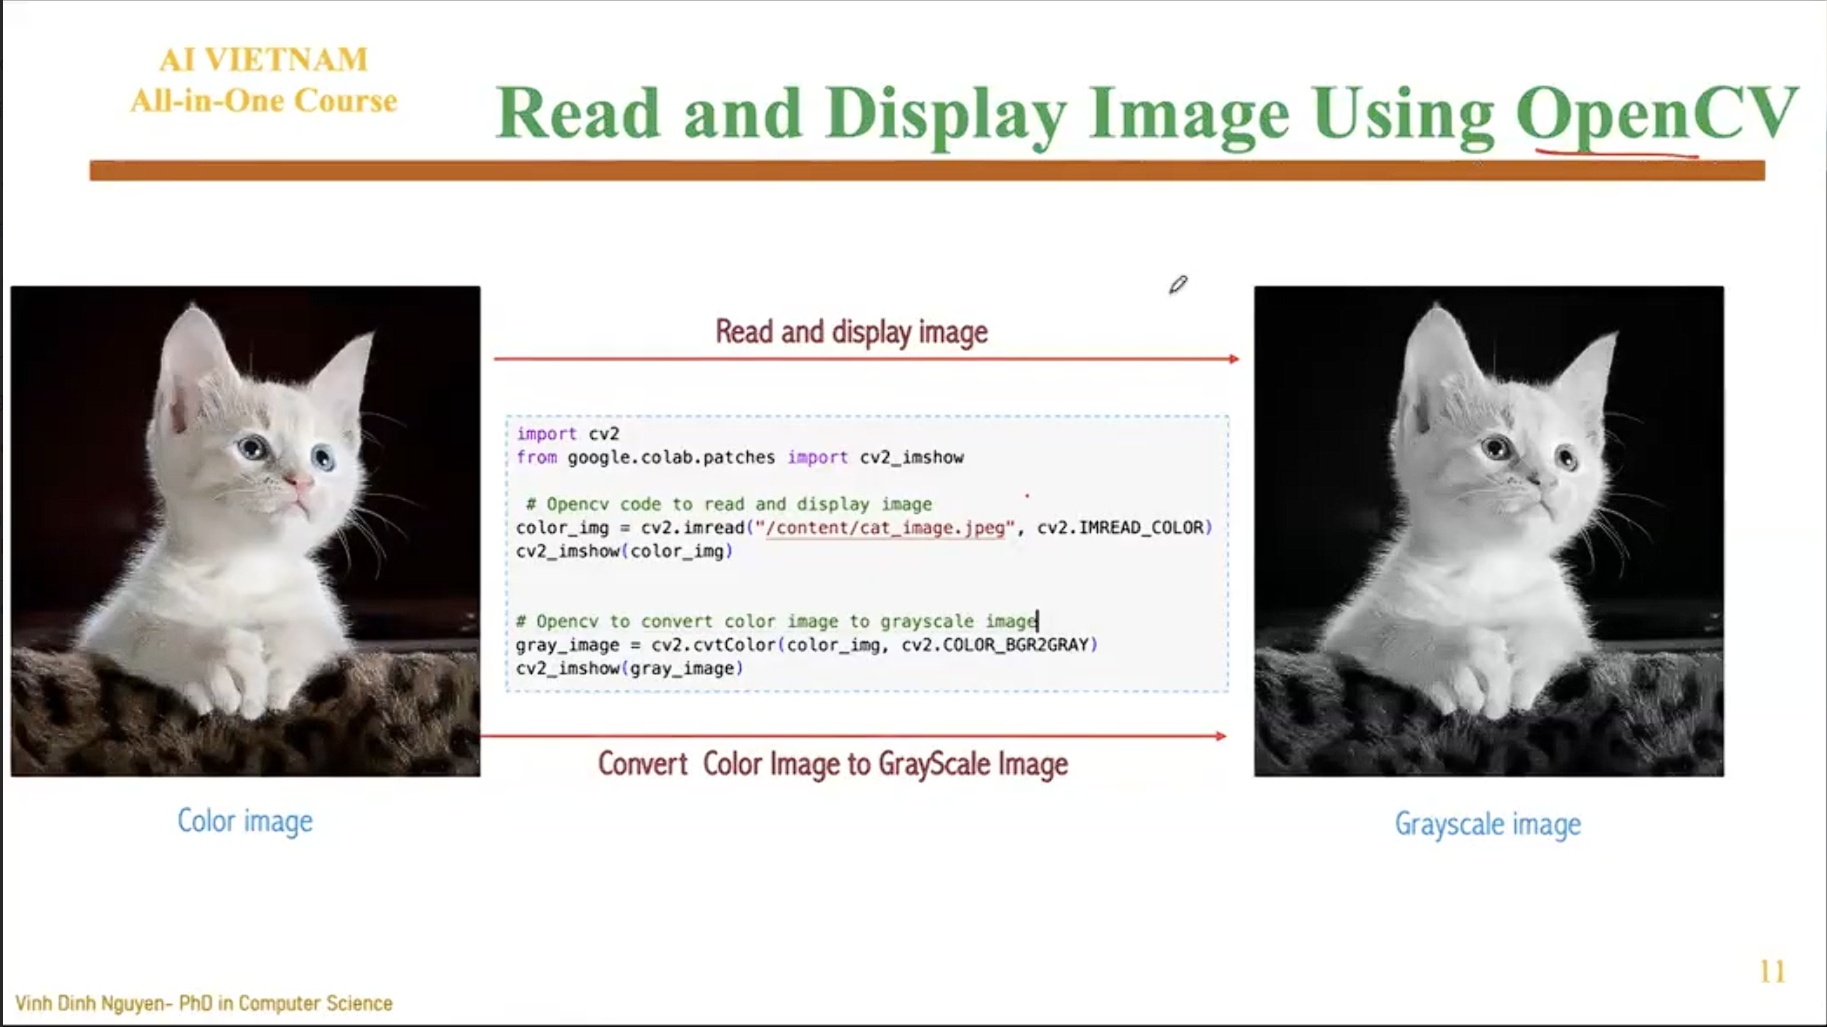

- Để đọc ảnh xám trực tiếp bằng imread, ta thường dùng cờ cv2.IMREAD_GRAYSCALE (hoặc truyền số 0): cv2.imread("image.jpg", cv2.IMREAD_GRAYSCALE).
- Thực chất, OpenCV không lấy trung bình cộng đơn giản của 3 ma trận theo kiểu (R + G + B) / 3. Thay vào đó, nó tính trung bình có trọng số (weighted average) của từng điểm ảnh (pixel) trên 3 kênh màu.

**Công thức cụ thể OpenCV sử dụng**

$$Gray = 0.299 \times R + 0.587 \times G + 0.114 \times B$$

- Kênh Green (Xanh lá - 58.7%): Mắt người có nhiều tế bào nón nhạy cảm với dải ánh sáng xanh lá nhất. Do đó, màu xanh lá quyết định phần lớn độ sáng/tối (luminance) mà ta cảm nhận được.
- Kênh Red (Đỏ - 29.9%): Độ nhạy của mắt với màu đỏ đứng thứ hai.
- Kênh Blue (Xanh dương - 11.4%): Mắt người ít nhạy cảm với ánh sáng xanh dương nhất, nên nó đóng góp ít nhất vào độ sáng tổng thể của bức ảnh xám.

In [ ]:
import cv2

color_img = cv2.imread('path', cv2.IMREAD_COLOR)
cv2.imshow(color_img)

# Convert color to grayscale image
gray_img = cv2.imread('path', cv2.IMREAD_GRAYSCALE)
cv2.imshow(gray_img)

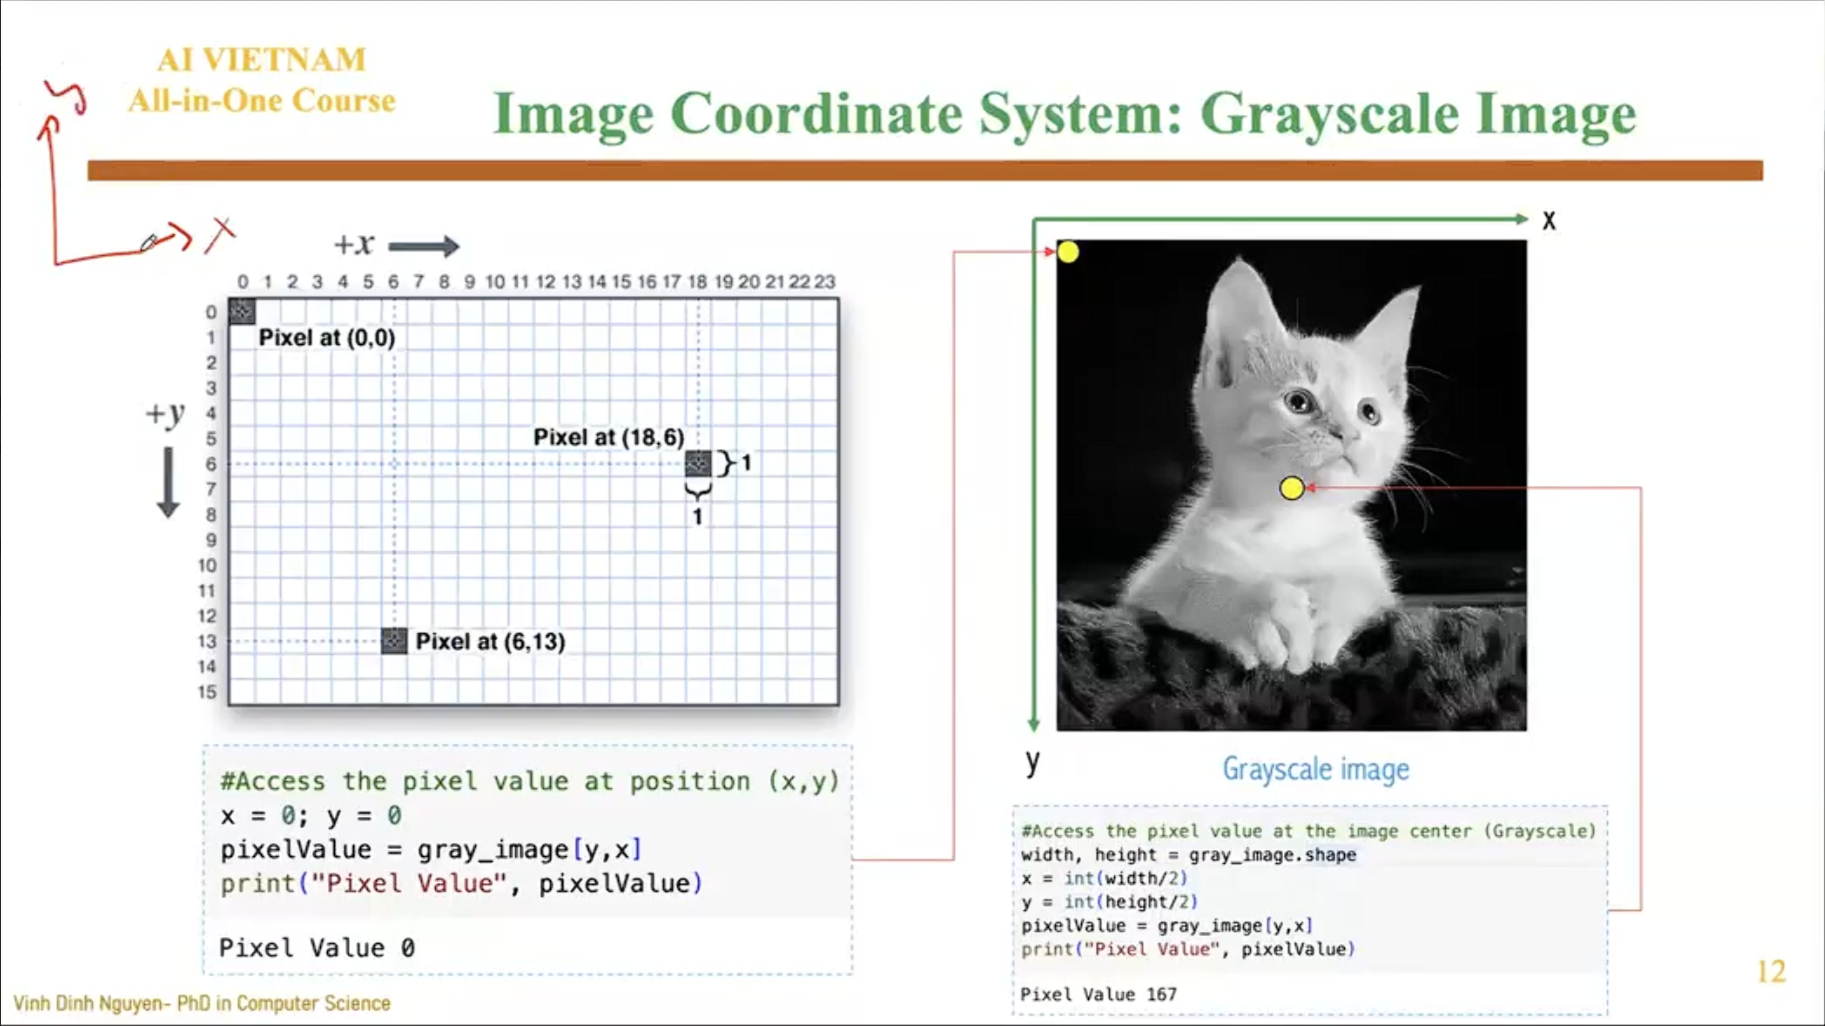

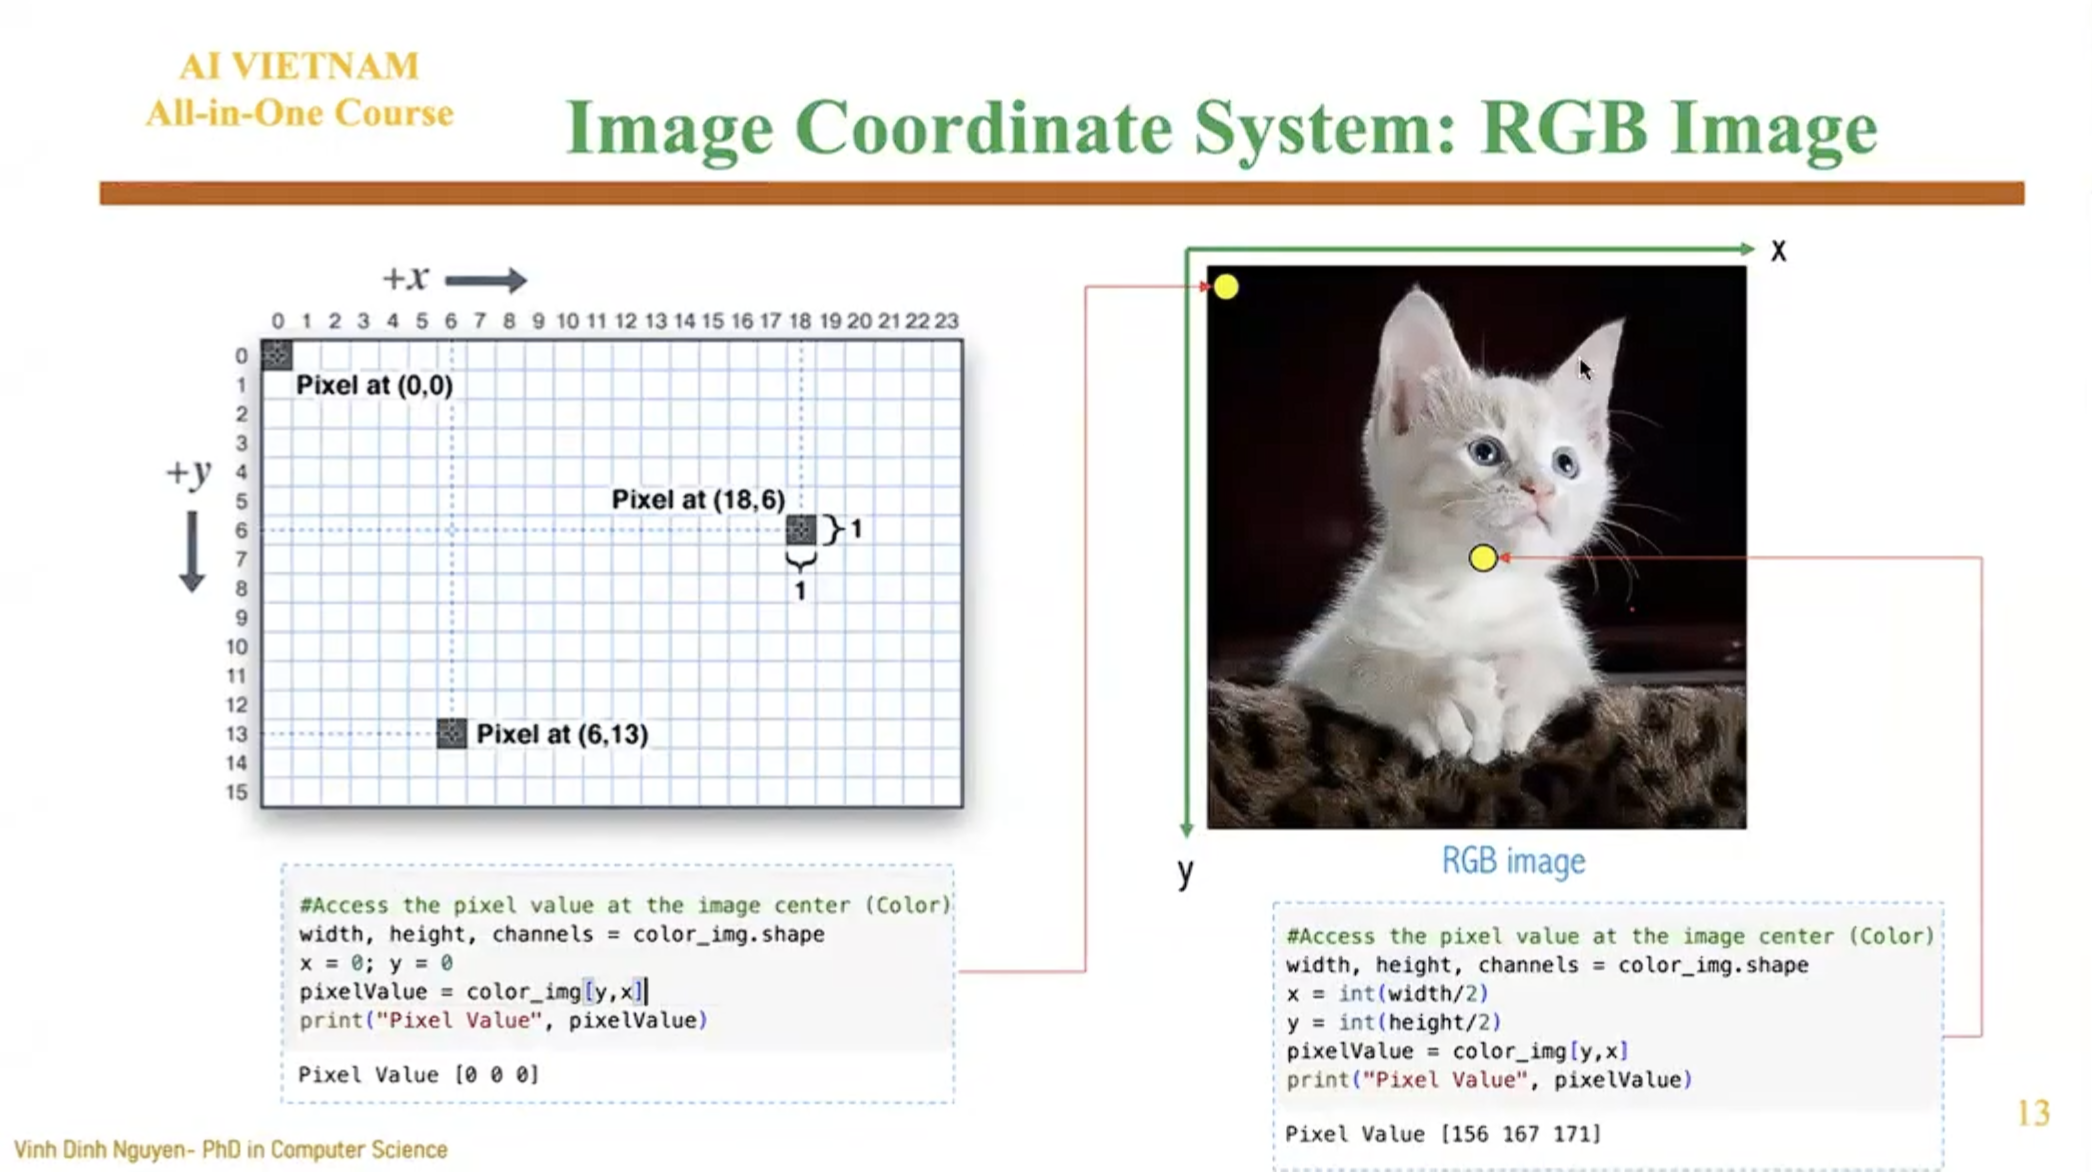

# EDGE DETECTION

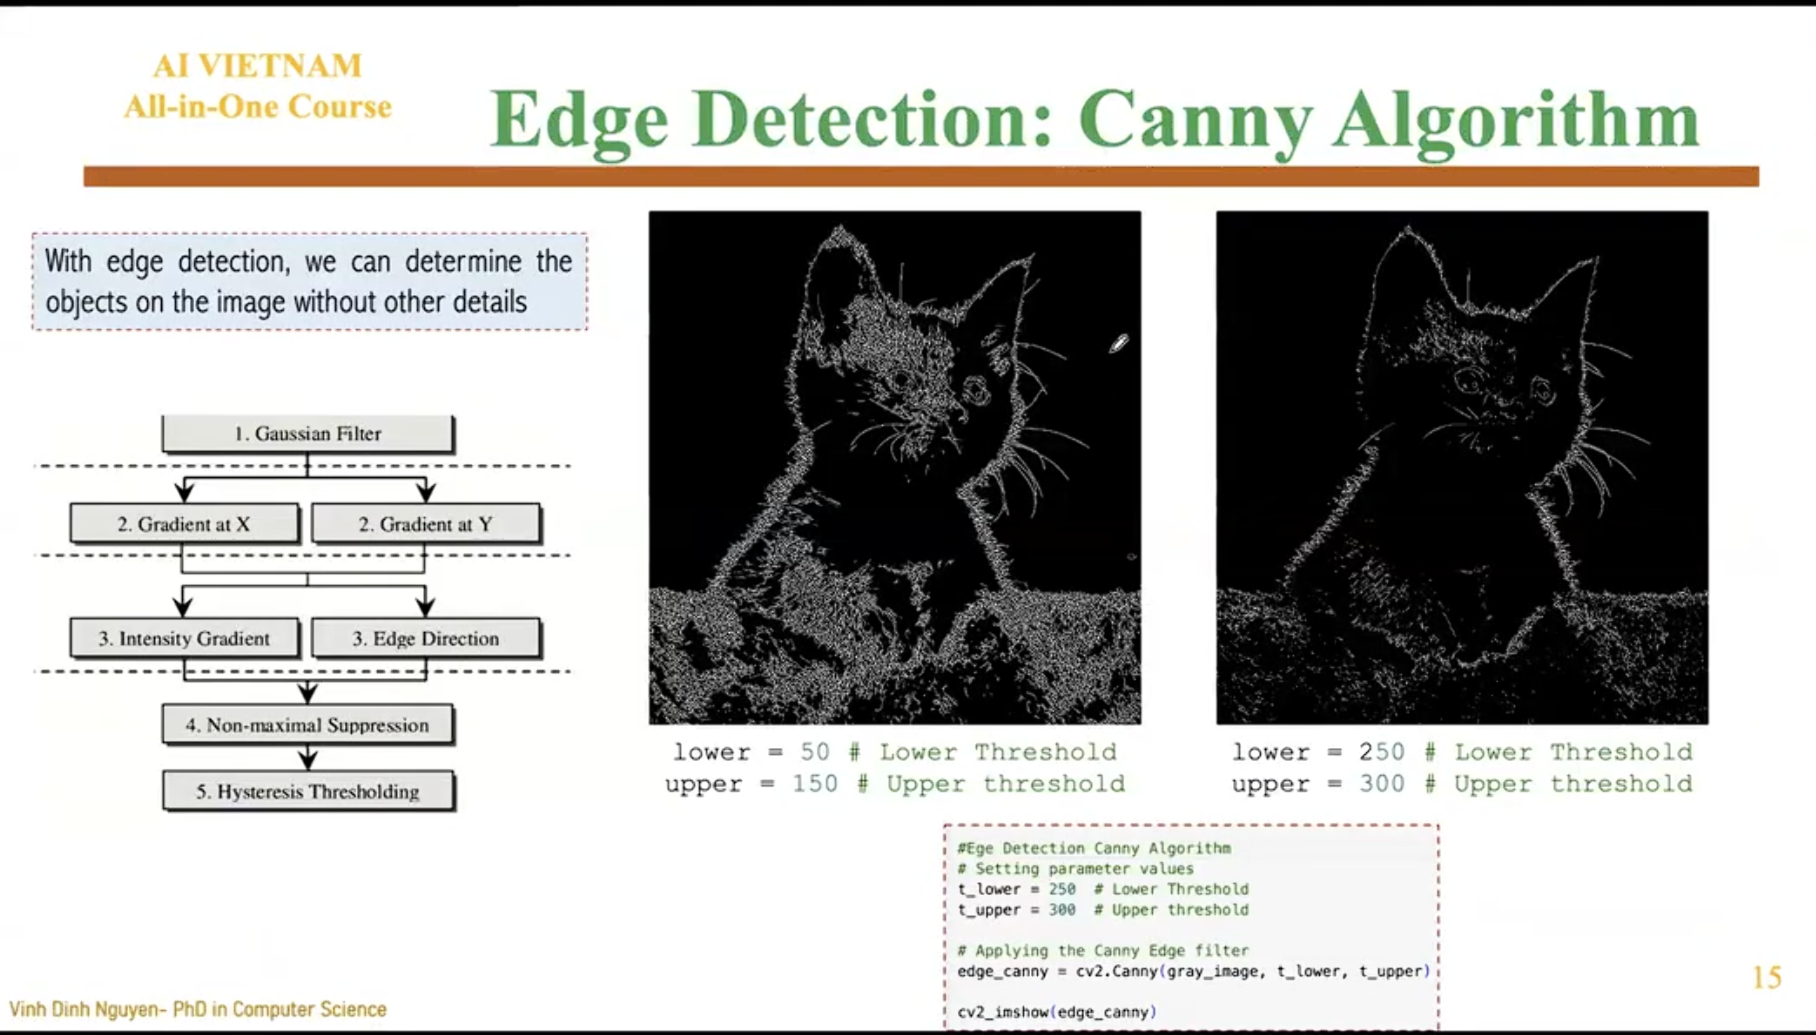

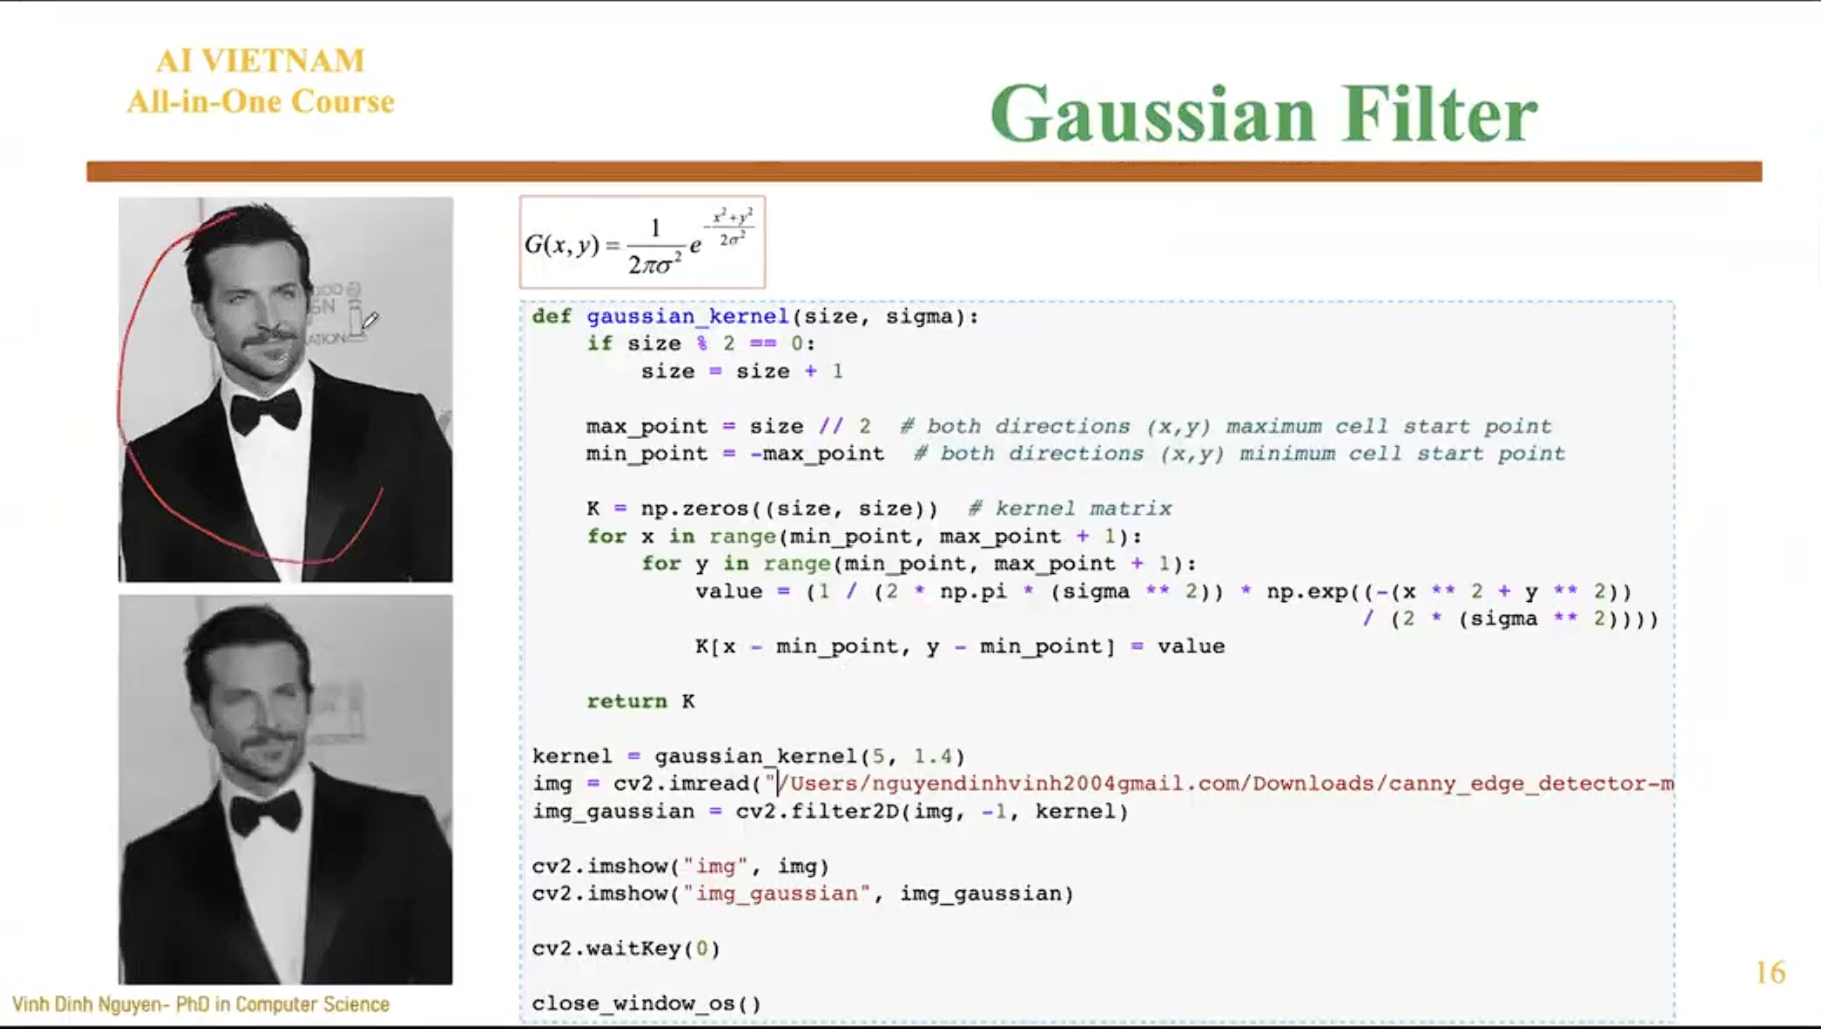

**1. Tại sao phải dùng Gaussian Filter trong dò biên (Edge Detection)?**

- Bản chất của việc tìm cạnh (edge) trong ảnh là tìm những nơi mà cường độ sáng (pixel intensity) thay đổi đột ngột (ví dụ: từ màu đen chuyển gắt sang màu trắng). Để tìm sự thay đổi này, máy tính dùng phép tính đạo hàm.
- Tuy nhiên, hình ảnh thực tế luôn chứa nhiễu (noise) - những hạt sạn nhỏ ngẫu nhiên. Nếu tính đạo hàm trực tiếp trên ảnh có nhiễu, máy tính sẽ nhầm lẫn những hạt nhiễu đó là các cạnh, dẫn đến kết quả tìm biên bị sai lệch nghiêm trọng (bức ảnh sẽ chi chít những đường nét vụn vặt).
Nhiệm vụ của Gaussian Filter là làm mờ ảnh (blur) để khử nhiễu, làm cho bức ảnh mịn hơn trước khi tiến hành tính đạo hàm tìm cạnh. Nó giữ lại được các cấu trúc lớn (cạnh thật) và xóa đi các chi tiết vụn vặt (nhiễu).

**2. Gaussian Filter hoạt động như thế nào?**

- Thay vì lấy trung bình cộng đơn giản của các pixel xung quanh (Average Filter) làm cho ảnh bị mờ một cách thô bạo và làm nhòe luôn cả các cạnh thật, Gaussian Filter lấy trung bình có trọng số dựa trên hàm phân phối chuẩn Gaussian (hình quả chuông).
- Điểm ảnh ở vị trí trung tâm sẽ có trọng số cao nhất (đóng góp nhiều nhất vào kết quả), và trọng số giảm dần khi đi ra xa trung tâm. Điều này giúp ảnh vừa sạch nhiễu mà vẫn bảo toàn được độ sắc nét của các đường biên tốt hơn.
- Công thức toán học của bộ lọc Gaussian 2 chiều được biểu diễn như sau:
$$G(x, y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}$$
- Trong đó:
    - $x, y$ là khoảng cách tính từ điểm gốc (tâm của bộ lọc).
    - $\sigma$ (Sigma) là độ lệch chuẩn, quyết định độ mờ của ảnh. $\sigma$ càng lớn, biểu đồ hình chuông càng bè ra, ảnh càng mờ.

In [14]:
import math

# ==========================================
# 1. HÀM TẠO MA TRẬN GAUSSIAN
# ==========================================
def create_gaussian_kernel(size, sigma):
    """
    Tạo ma trận Gaussian vuông kích thước size x size.
    Lưu ý: size bắt buộc phải là số lẻ (ví dụ: 3, 5, 7).
    """
    kernel = []
    center = size // 2
    sum_val = 0.0

    for i in range(size):
        row = []
        for j in range(size):
            # Tính khoảng cách x, y tính từ tâm ma trận
            x = i - center
            y = j - center

            exponent = math.exp(-(x**2 + y**2) / (2 * sigma**2))
            value = (1 / 2 * math.pi * sigma**2) * exponent

            row.append(value)
            sum_val += value
        kernel.append(row)
    
    # Chuẩn hóa: Chia từng phần tử cho tổng để đảm bảo tổng = 1
    for i in range(size):
        for j in range(size):
            kernel[i][j] = kernel[i][j] / sum_val
    return kernel


# ==========================================
# 2. HÀM TÍCH CHẬP (CONVOLUTION) LÀM MỜ ẢNH
# ==========================================
def apply_gaussian_filter(image, kernel):
    """
    Quét kernel qua ảnh 2 chiều.
    image: list of lists chứa giá trị pixel (0-255).
    """
    img_height = len(image)
    img_width = len(image[0])
    kernel_size = len(kernel)
    pad = kernel_size // 2

    # Tạo một bức ảnh rỗng (toàn số 0) có cùng kích thước để chứa kết quả
    result = [[0 for _ in range(img_width)] for _ in range(img_height)]

    # Quét qua từng pixel của ảnh gốc
    # (Bỏ qua các viền ngoài cùng bằng kích thước 'pad' để tránh lỗi vượt quá mảng)
    for i in range(pad, img_height - pad):
        for j in range(pad, img_width - pad):

            new_pixel_val = 0.0

            # Quét ma trận kernel lên vùng ảnh xung quanh pixel (i, j)
            for ki in range(kernel_size):
                for kj in range(kernel_size):
                    img_x = i + ki - pad
                    img_y = j + kj - pad

                    # Nhân chập và cộng dồn
                    new_pixel_val += image[img_x][img_y] * kernel[ki][kj]
                
            # Ép kiểu về số nguyên và đảm bảo giá trị nằm trong khoảng [0, 255]
            result[i][j] = max(0, min(int(new_pixel_val), 255))
    return result

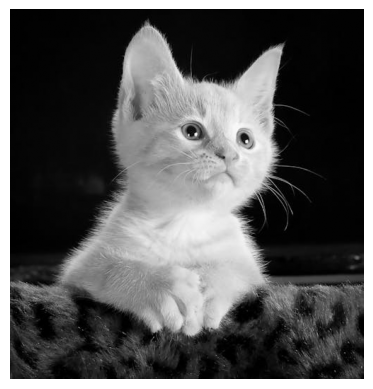

In [8]:
import matplotlib.pyplot as plt
import cv2
img = cv2.imread(r'C:\Code_AI\AIO_Code\Module5\IntroToCV\cat.jpeg', cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

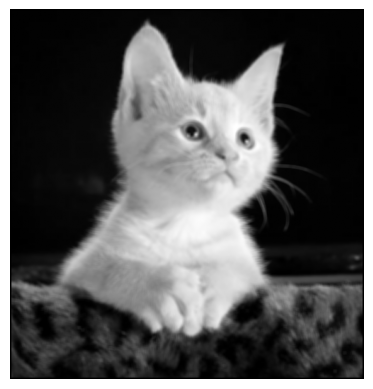

In [18]:
kernel = create_gaussian_kernel(size=5, sigma=10.0)
blurred_image = apply_gaussian_filter(img, kernel)
plt.imshow(blurred_image, cmap='gray')
plt.axis('off')
plt.show()

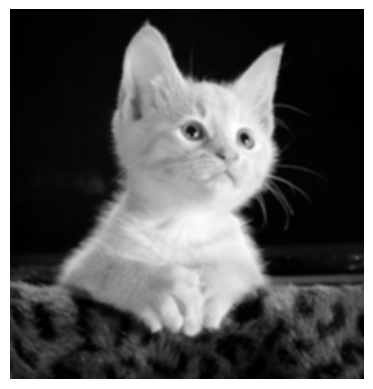

In [20]:
import numpy as np
kernel_list = create_gaussian_kernel(5, 10.0)
kernel_numpy = np.array(kernel_list, dtype=np.float32)

img_gaussian = cv2.filter2D(img, -1, kernel_numpy)

plt.imshow(img_gaussian, cmap='gray')
plt.axis('off') 
plt.show()

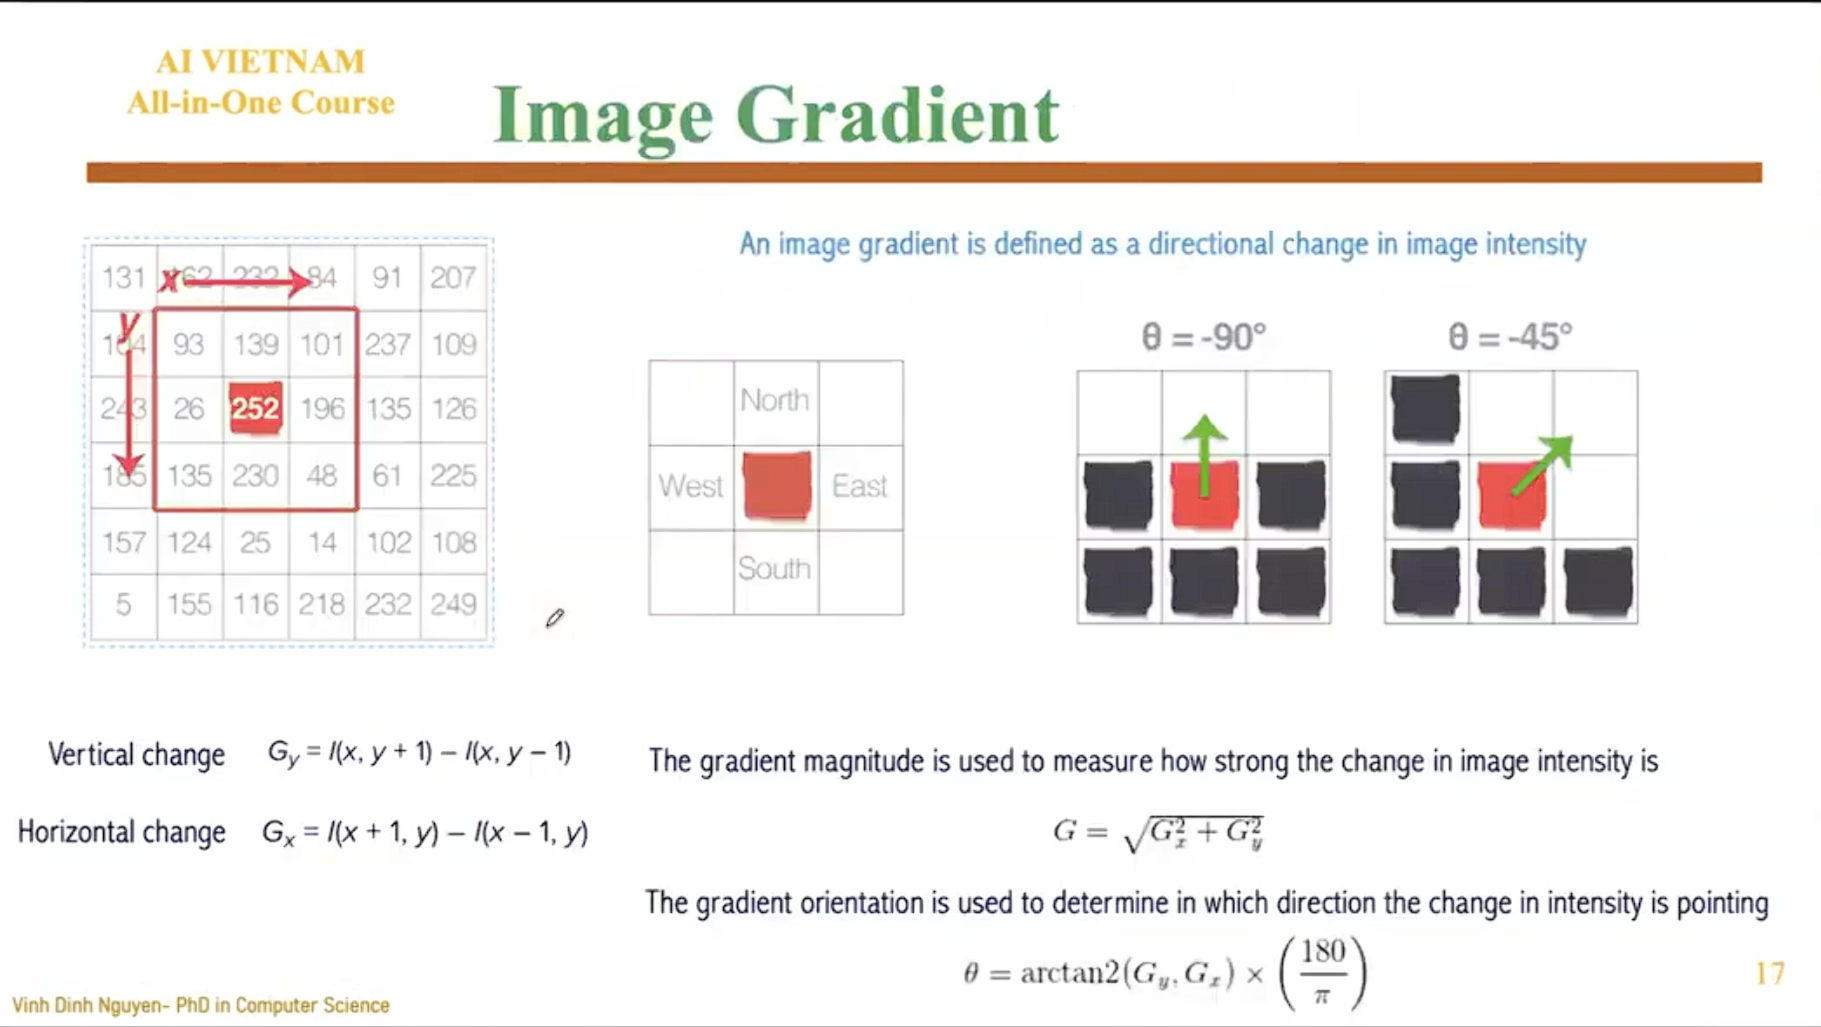

**1. Có phải luôn luôn tính gradient bằng cách lấy pixel liền trước và liền sau không?**

- Không hoàn toàn đúng. Trong bức ảnh, công thức $G_y$ và $G_x$ đang sử dụng phương pháp cơ bản nhất gọi là sai phân trung tâm (Central Difference): lấy pixel ngay liền sau trừ đi pixel ngay liền trước nó.
- Tuy nhiên, trong thực tế xử lý ảnh, việc chỉ dùng đúng 2 pixel kề nhau như vậy tiềm ẩn rủi ro rất lớn: cực kỳ nhạy cảm với nhiễu (noise). Chỉ cần 1 pixel bị nhiễu sáng lên bất thường, kết quả gradient sẽ bị sai lệch hoàn toàn.
- Do đó, các thuật toán hiện đại (như Sobel hay Prewitt) không dùng cách trừ trực tiếp 2 pixel này, mà chúng sử dụng các ma trận (kernel) kích thước 3x3 hoặc 5x5. Việc này nhằm mục đích kết hợp thêm trọng số của các pixel xung quanh để "làm mềm" sự thay đổi, giúp tính toán gradient chính xác và kháng nhiễu tốt hơn rất nhiều. Công thức trong hình là nền tảng lý thuyết cơ bản nhất để dễ hiểu bản chất.

**2. Tính độ lớn của gradient ($G$) có tác dụng gì?**

- Tác dụng thực tế: Giá trị $G = \sqrt{G_x^2 + G_y^2}$ chính là "chiếc máy dò" để tìm ra các góc cạnh trên ảnh.
- Nếu $G$ nhỏ (gần 0), có nghĩa là màu sắc khu vực đó rất đồng đều, không có sự biến thiên (ví dụ: một mảng tường trắng).
- Nếu $G$ rất lớn, có nghĩa là tại điểm đó độ sáng bị thay đổi cực kỳ đột ngột (ví dụ: chuyển gắt từ áo màu đen sang phông nền màu trắng). Sự thay đổi đột ngột này chính xác là đường biên (edge) mà máy tính đang cần tìm.

**3. Công thức tính góc bằng hàm $\arctan$ cuối cùng có tác dụng gì?**

- Hàm $\arctan2$ giúp máy tính tìm ra góc $\theta$ (đơn vị radian) của vector gradient.
- Phần nhân với $\frac{180}{\pi}$ chỉ đơn giản là phép toán đổi từ radian sang độ (degrees) để con người dễ đọc hơn (như góc -90° hay -45° minh họa trên hình).

- Tác dụng thực tế trong Dò biên (Canny): Tính ra hướng của cạnh là một bước bắt buộc phải có. Nhờ biết được cạnh đang nằm ngang, nằm dọc hay nằm chéo, thuật toán Canny sẽ thực hiện một bước gọi là Non-maximum Suppression (Lọc cực đại cục bộ) dọc theo hướng vuông góc với cạnh đó. Bước này có nhiệm vụ loại bỏ các pixel mờ nhạt xung quanh, giúp gọt giũa đường viền dày cộm trở thành một đường biên cực kỳ sắc nét, mỏng đúng 1 pixel!

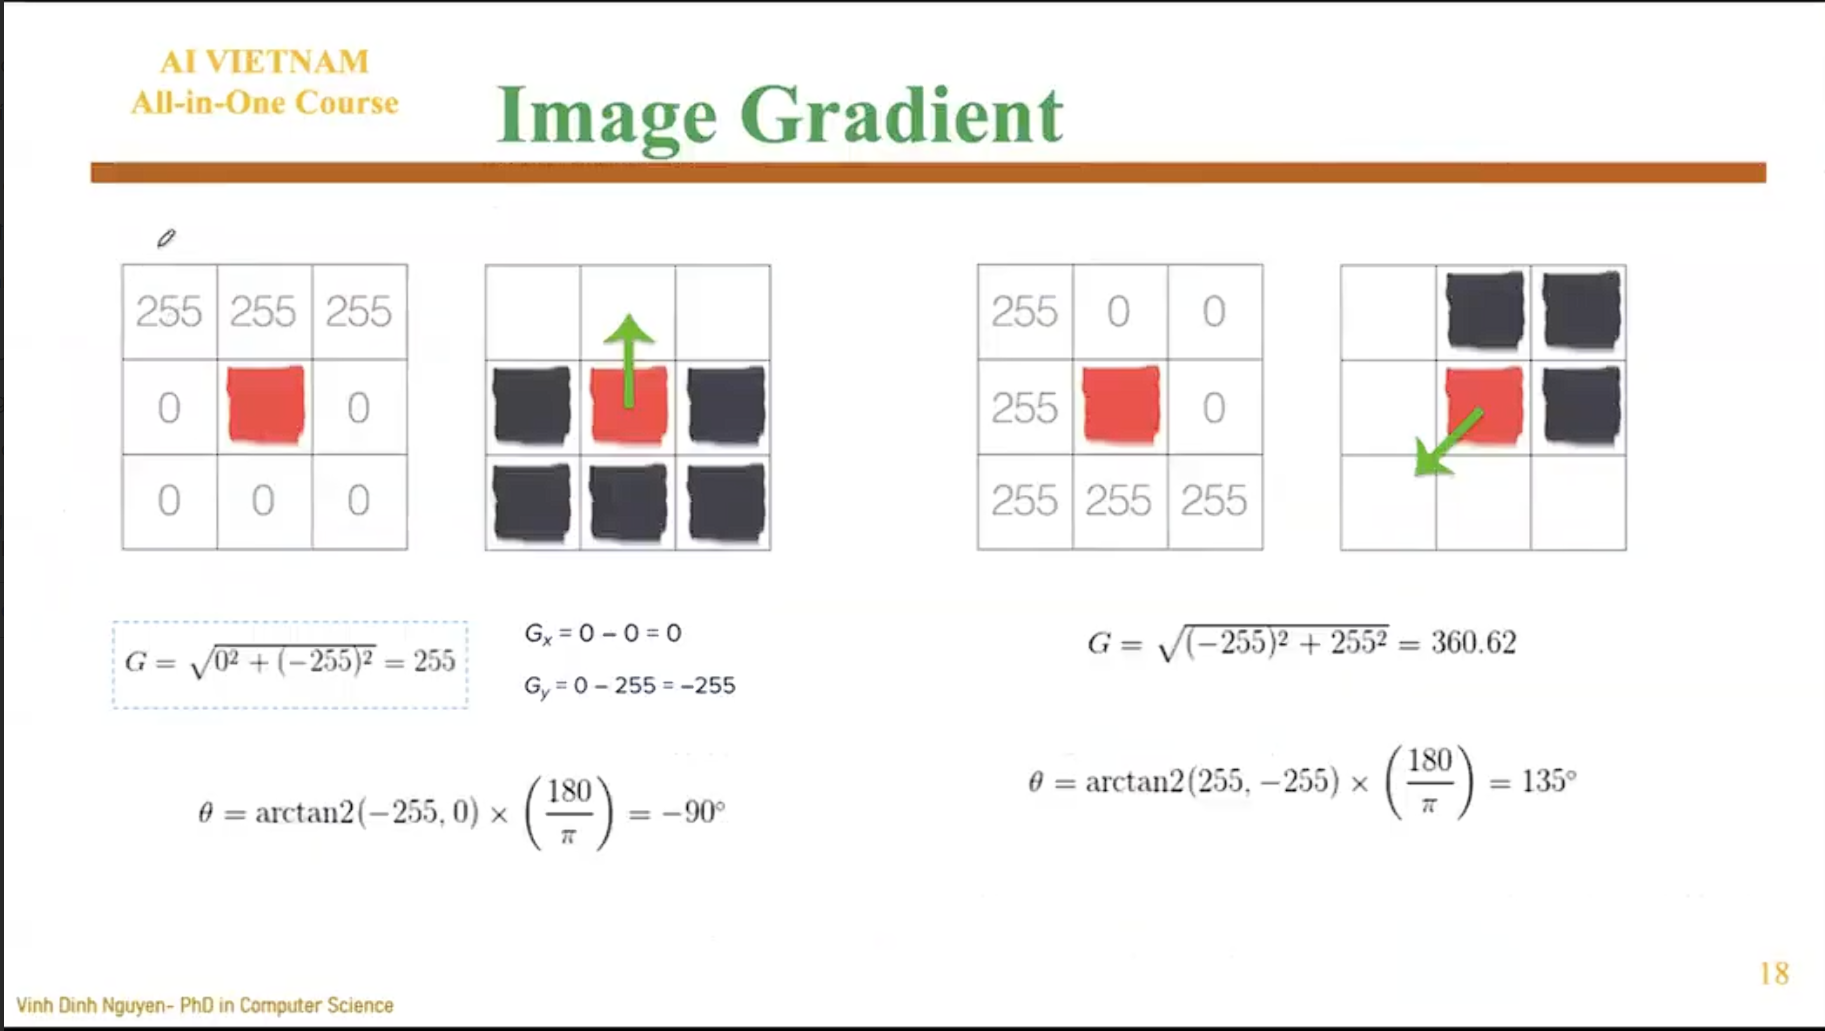

